In [1]:
# Filename......: FP_MoviewReviews_OlisBahari
# Language......: Python
# Tools.........: Google Colab
# Class.........: ITAI 1371 Introduction to Machine Learning
# Semester......: Summer 2026
# Class Type....: Online
# Instructor....: Sitaram Ayyagari
# Student.......: Olis Bahari
# Version.......: V1.0
# Purpose.......: Final Project: Movie Reviews Sentiment Classification.

##Part 1: Project Definition

This project aims to build and compare machine learning models that classify movie reviews as either positive or negative. It uses the NLTK Movie Reviews dataset, looks at the text and class distribution, preprocesses the reviews, turns the text into TF-IDF features, trains several classifiers, and checks how well they perform.

Models Compared

* Logistic Regression
* Multinomial Naive Bayes
* Linear Support Vector Machine (LinearSVC)

The best model is chosen based on the weighted F1-score. The project also looks at accuracy, precision, recall, confusion matrices, training time, and examples of misclassified reviews.


In [2]:
# Import necessary libraries
import re
import string
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Core libraries imported successfully!")


Core libraries imported successfully!


## Part 2: EDA

This section loads the NLTK Movie Reviews dataset, checks its structure and data quality, examines class balance and review lengths, and explores frequently occurring words in positive and negative reviews.


In [3]:

# Load the NLTK Movie Reviews public sentiment dataset.
import nltk
nltk.download('movie_reviews', quiet=True)

from nltk.corpus import movie_reviews

records = []
for file_id in movie_reviews.fileids():
    sentiment = movie_reviews.categories(file_id)[0]
    review_text = movie_reviews.raw(file_id)
    records.append({'text': review_text, 'sentiment': sentiment})

df = pd.DataFrame(records)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
display(df.head())


Dataset shape: (2000, 2)

Column names: ['text', 'sentiment']


,text,sentiment
0,the verdict : spine-chilling drama from horror...,pos
1,""" the 44 caliber killer has struck again . "" ...",neg
2,in the company of men made a splash at the sun...,pos
3,"in the year 2029 , captain leo davidson ( mark...",neg
4,[note that followups are directed to rec . art...,pos


In [4]:

# Check dataset structure, missing values, and duplicates
print("Dataset Information")
print("=" * 50)
df.info()

print("\nMissing Values")
print("=" * 50)
print(df.isnull().sum())

print("\nDuplicate Rows")
print("=" * 50)
print(f"Duplicate rows: {df.duplicated().sum()}")

df = df.dropna(subset=['text', 'sentiment']).drop_duplicates().reset_index(drop=True)
print(f"\nClean dataset shape: {df.shape}")


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       2000 non-null   object
 1   sentiment  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB

Missing Values
text         0
sentiment    0
dtype: int64

Duplicate Rows
Duplicate rows: 0

Clean dataset shape: (2000, 2)


In [5]:

# The full dataset has only 2,000 reviews, so no sampling is necessary.
print(f"Working with all {len(df):,} reviews.")


Working with all 2,000 reviews.


,Count,Percent
sentiment,,
neg,1000,50.0
pos,1000,50.0


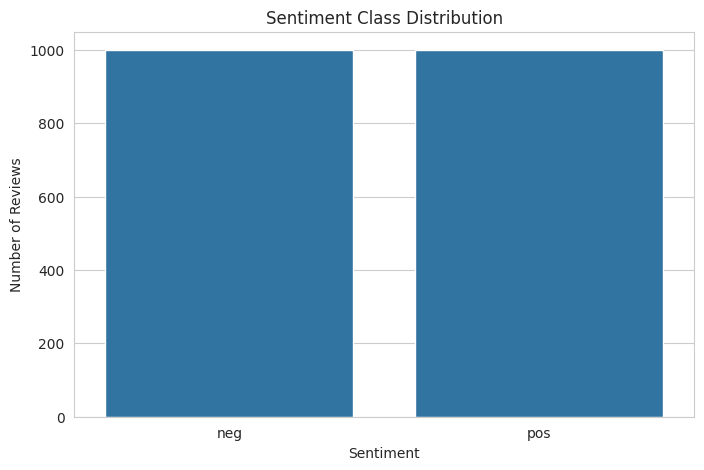

In [6]:

# Analyze sentiment distribution
sentiment_counts = df['sentiment'].value_counts().sort_index()
sentiment_percent = df['sentiment'].value_counts(normalize=True).sort_index() * 100

distribution = pd.DataFrame({
    'Count': sentiment_counts,
    'Percent': sentiment_percent.round(2)
})
display(distribution)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment', order=['neg', 'pos'])
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


Charcter Length Summary


,text_length_chars
count,2000.00
mean,3893.00
std,1712.43
min,91.00
25%,2737.75
50%,3622.50
75%,4720.25
max,14957.00



Word Count By SENTIMENT


,count,mean,median,min,max
sentiment,,,,,
neg,1000,705.63,668.5,17,2181
pos,1000,787.05,731.5,130,2678


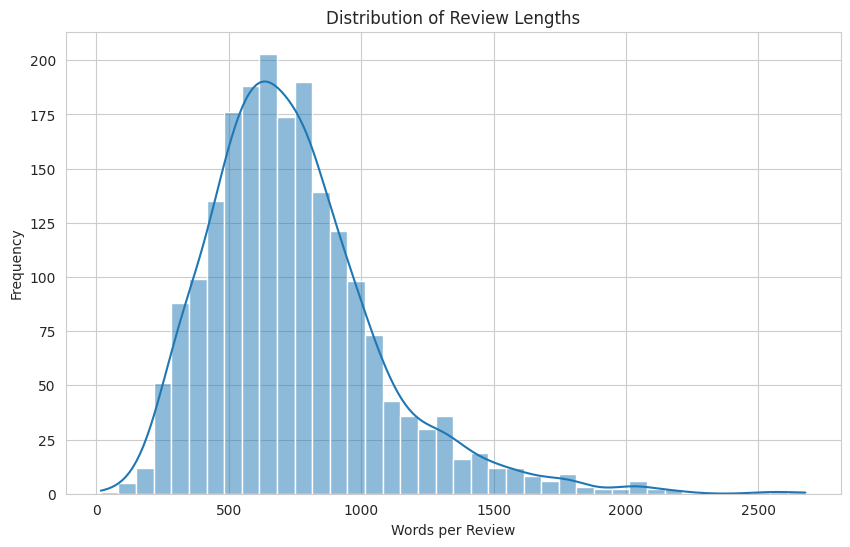

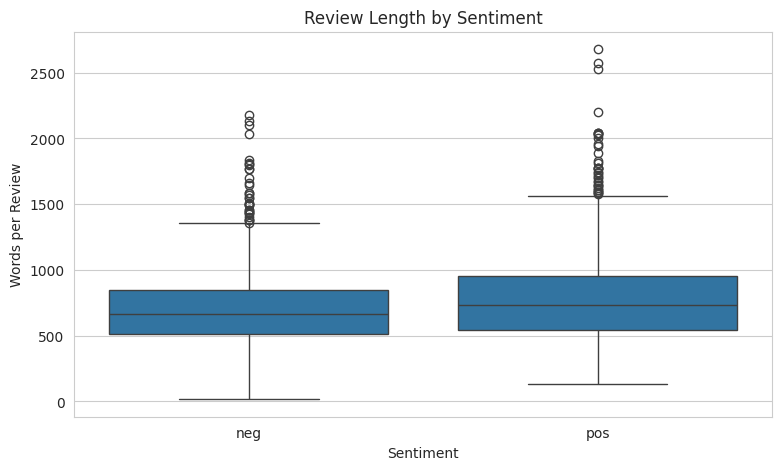

In [7]:

# Analyze text length distribution
df['text_length_chars'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("Charcter Length Summary")
display(df['text_length_chars'].describe().round(2).to_frame())

print("\nWord Count By SENTIMENT")
display(
    df.groupby('sentiment')['word_count']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .round(2)
)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', bins=40, kde=True)
plt.title('Distribution of Review Lengths')
plt.xlabel('Words per Review')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='sentiment', y='word_count', order=['neg', 'pos'])
plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Words per Review')
plt.show()


In [8]:

# Display sample reviews from each sentiment class
for sentiment_label in ['neg', 'pos']:
    print("\n" + "=" * 90)
    print(f"SAMPLE {sentiment_label.upper()} REVIEWS")
    print("=" * 90)

    samples = df[df['sentiment'] == sentiment_label].sample(2, random_state=42)
    for _, row in samples.iterrows():
        preview = row['text'].replace('\n', ' ')[:700]
        print(f"\n{preview}...")
        print("-" * 90)



SAMPLE NEG REVIEWS

the classic story & the production which ruined it  marking the centennial anniversary of the 1896 h . g . wells classic , new line cinema , armed with a stellar cast and expert make-up effects man stan winston ( alien , predator , terminator etc ) churns out yet another hollywood film based on the classic novel .  of course , the production is no doubt much more superior compared to the earlier 2 movies , one of which was made back in the 1933 and the other in the 1977 , under the title the island of lost souls ( sounds like a much better title . . ) .  the story begins with edward douglas ( thewlis ) , a un representative sent to oversee a peace treaty somewhere in the south pacific , who ...
------------------------------------------------------------------------------------------

numerous comparisons can be made with this movie to past sci-fi , suspense thrillers .  soldier is a multi ? crossbreed between the likes of terminator , aliens and offspring .  the p

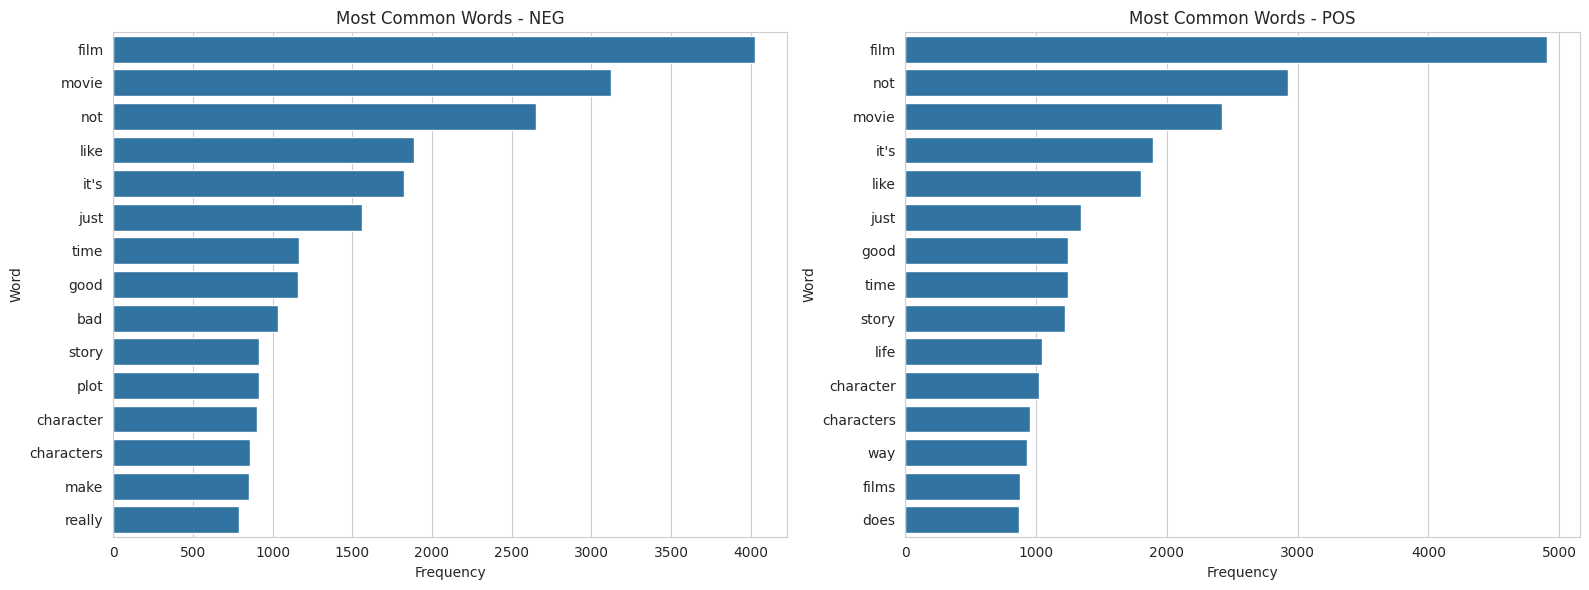

In [9]:

# Analyze common words after simple token cleanup
negation_words = {'not', 'no', 'nor', 'never'}
stop_words_for_frequency = set(ENGLISH_STOP_WORDS) - negation_words

def simple_tokens(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s']", " ", text)
    return [w for w in text.split()
            if len(w) > 2 and w not in stop_words_for_frequency]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sentiment_label in zip(axes, ['neg', 'pos']):
    words = []
    for text in df.loc[df['sentiment'] == sentiment_label, 'text']:
        words.extend(simple_tokens(text))

    common = Counter(words).most_common(15)
    common_df = pd.DataFrame(common, columns=['word', 'count'])
    sns.barplot(data=common_df, x='count', y='word', ax=ax)
    ax.set_title(f"Most Common Words - {sentiment_label.upper()}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Word")

plt.tight_layout()
plt.show()


In [10]:
# Preprocessing tools were imported in the first cell so that earlier EDA cells
# can safely use regular expressions and scikit-learn stop words.
print("Preprocessing libraries are ready!")


Preprocessing libraries are ready!


##Part 3: Preprocessing & Feature Extraction

To prepare the reviews, the text is changed to lowercase and any URLs, HTML tags, mentions, digits, or extra characters are removed. After cleaning, the data is divided into training and testing sets.

TF-IDF is trained using only the training data, and then the same transformation is applied to the test data. This approach helps make sure that no information from the test set influences the model during training.


In [11]:

# Create a text preprocessing function
def preprocess_text(text):
    '''
    Clean and normalize movie-review text while preserving useful words.
    '''
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r"[^a-z\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

sample_text = "This is a TEST!!! Check out https://example.com @user #Amazing 123 -- don't miss it."
print(f"Original: {sample_text}")
print(f"Cleaned:  {preprocess_text(sample_text)}")


Original: This is a TEST!!! Check out https://example.com @user #Amazing 123 -- don't miss it.
Cleaned:  this is a test check out amazing don't miss it


In [12]:

# Apply preprocessing to the dataset
df['cleaned_text'] = df['text'].apply(preprocess_text)
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

print("Text preprocessing complete!")
display(df[['text', 'cleaned_text', 'sentiment']].head(3))


Text preprocessing complete!


,text,cleaned_text,sentiment
0,the verdict : spine-chilling drama from horror...,the verdict spine chilling drama from horror m...,pos
1,""" the 44 caliber killer has struck again . "" ...",the caliber killer has struck again starring j...,neg
2,in the company of men made a splash at the sun...,in the company of men made a splash at the sun...,pos


In [13]:

# Prepare features (X) and target (y)
X = df['cleaned_text']
y = df['sentiment']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print("\nTarget distribution:")
print(y.value_counts())


Features shape: (2000,)
Target shape:   (2000,)

Target distribution:
sentiment
pos    1000
neg    1000
Name: count, dtype: int64


In [14]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())


Training samples: 1600
Testing samples:  400

Training class distribution:
sentiment
pos    800
neg    800
Name: count, dtype: int64

Testing class distribution:
sentiment
neg    200
pos    200
Name: count, dtype: int64


In [15]:

# Create TF-IDF features
negation_words = {'not', 'no', 'nor', 'never'}
custom_stop_words = sorted(set(ENGLISH_STOP_WORDS) - negation_words)

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.90,
    ngram_range=(1, 2),
    stop_words=custom_stop_words,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")


TF-IDF matrix shape (train): (1600, 5000)
TF-IDF matrix shape (test):  (400, 5000)
Number of features: 5000


In [16]:

# Explore TF-IDF vocabulary
feature_names = tfidf.get_feature_names_out()

print("First 25 features:")
print(feature_names[:25])

print("\nLast 25 features:")
print(feature_names[-25:])

print(f"\nVocabulary size: {len(feature_names):,}")


First 25 features:
['abandoned' 'abilities' 'ability' 'able' 'aboard' 'absent' 'absolute'
 'absolutely' 'absolutely no' 'absurd' 'abuse' 'abyss' 'academy'
 'academy award' 'accent' 'accents' 'accept' 'acceptable' 'accepts'
 'accident' 'accidentally' 'acclaimed' 'accompanied' 'accomplish'
 'accomplished']

Last 25 features:
['written directed' 'wrong' 'wrote' 'yeah' 'year' 'year old' 'years'
 'years ago' 'years later' 'years old' 'yes' 'york' 'york city' 'young'
 'young boy' 'young girl' 'young man' 'young woman' 'younger' 'youth'
 'zany' 'zero' 'zeta' 'zeta jones' 'zone']

Vocabulary size: 5,000


##Part 4: Modeling

We train three classification algorithms using the same TF-IDF training matrix to ensure a fair comparison of their performance.
1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear SVM

In [17]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import time
from datetime import timedelta

print("Model libraries imported!")

Model libraries imported!


In [18]:

# Train Logistic Regression
print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

lr_training_time = time.time() - start_time
print(f"Training complete in {lr_training_time:.3f} seconds")


Training Logistic Regression...
Training complete in 0.168 seconds


In [19]:

# Make predictions with Logistic Regression
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_lr.shape}")


Predictions shape: (400,)


In [20]:

# Train Multinomial Naive Bayes
print("Training Multinomial Naive Bayes...")
start_time = time.time()

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

nb_training_time = time.time() - start_time
print(f"Training complete in {nb_training_time:.3f} seconds")


Training Multinomial Naive Bayes...
Training complete in 0.019 seconds


In [21]:

# Make predictions with Naive Bayes
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_nb.shape}")


Predictions shape: (400,)


In [22]:

# Train third model: Linear SVM
print("Training Linear SVM (LinearSVC)...")
start_time = time.time()

svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

svm_training_time = time.time() - start_time
y_pred_svm = svm_model.predict(X_test_tfidf)

print(f"Training complete in {svm_training_time:.3f} seconds")
print(f"Predictions shape: {y_pred_svm.shape}")


Training Linear SVM (LinearSVC)...
Training complete in 0.101 seconds
Predictions shape: (400,)


##Part 5: Evaluation

We evaluate each model using accuracy, weighted precision, weighted recall, weighted F1-score, a classification report, and a confusion matrix. After that, we rank the models based on their weighted F1-score.


In [23]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Evaluation metrics imported!")

Evaluation metrics imported!


In [24]:

# Evaluate Logistic Regression
print("=" * 55)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 55)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print(f"Accuracy:  {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall:    {rec_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, digits=4, zero_division=0))


LOGISTIC REGRESSION RESULTS
Accuracy:  0.8350
Precision: 0.8350
Recall:    0.8350
F1-Score:  0.8350

Classification Report:
              precision    recall  f1-score   support

         neg     0.8350    0.8350    0.8350       200
         pos     0.8350    0.8350    0.8350       200

    accuracy                         0.8350       400
   macro avg     0.8350    0.8350    0.8350       400
weighted avg     0.8350    0.8350    0.8350       400



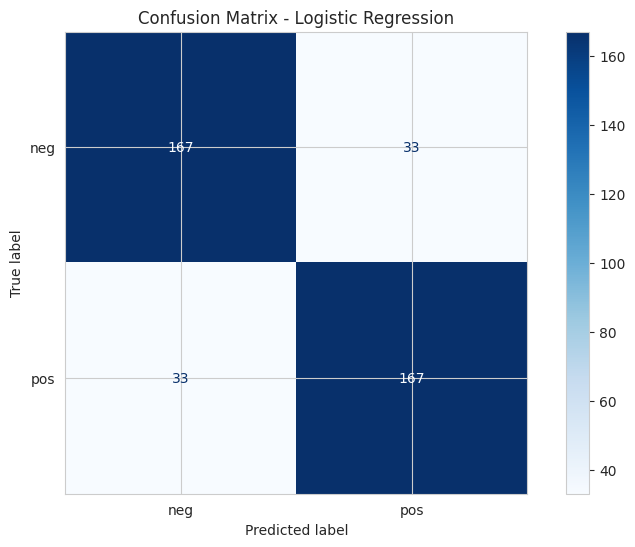

In [25]:

# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=lr_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


In [26]:

# Evaluate Naive Bayes
print("=" * 55)
print("Multinomial Naive Bayes Result")
print("=" * 55)

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
rec_nb = recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)

print(f"Accuracy:  {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall:    {rec_nb:.4f}")
print(f"F1-Score:  {f1_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, digits=4, zero_division=0))


Multinomial Naive Bayes Result
Accuracy:  0.8050
Precision: 0.8070
Recall:    0.8050
F1-Score:  0.8047

Classification Report:
              precision    recall  f1-score   support

         neg     0.7824    0.8450    0.8125       200
         pos     0.8315    0.7650    0.7969       200

    accuracy                         0.8050       400
   macro avg     0.8070    0.8050    0.8047       400
weighted avg     0.8070    0.8050    0.8047       400



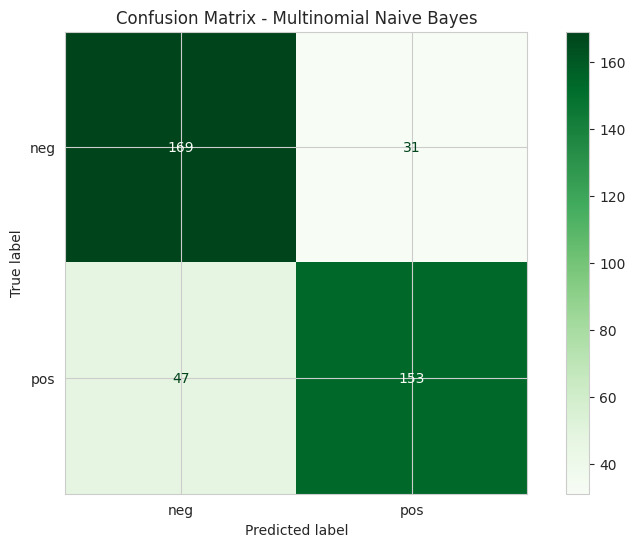

In [27]:

# Confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=nb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
disp.plot(cmap='Greens', values_format='d')
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.show()


In [28]:

# Evaluate Linear SVM
print("=" * 55)
print("Linear SVM Result")
print("=" * 55)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)

print(f"Accuracy:  {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall:    {rec_svm:.4f}")
print(f"F1-Score:  {f1_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, digits=4, zero_division=0))


Linear SVM Result
Accuracy:  0.8500
Precision: 0.8500
Recall:    0.8500
F1-Score:  0.8500

Classification Report:
              precision    recall  f1-score   support

         neg     0.8500    0.8500    0.8500       200
         pos     0.8500    0.8500    0.8500       200

    accuracy                         0.8500       400
   macro avg     0.8500    0.8500    0.8500       400
weighted avg     0.8500    0.8500    0.8500       400



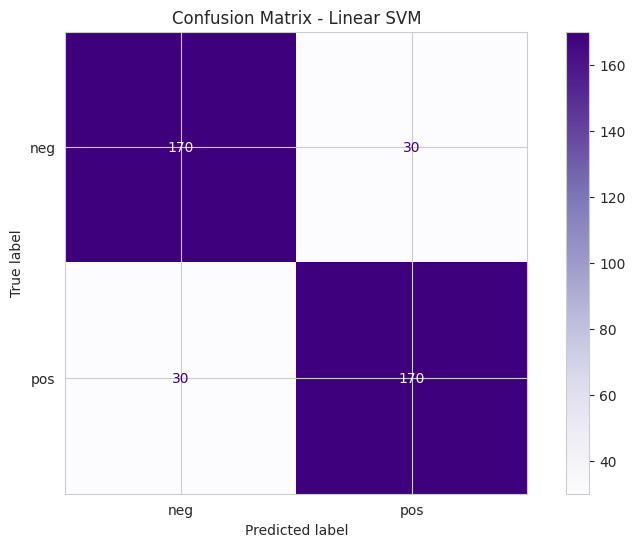

In [29]:

# Confusion matrix for Linear SVM
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)
disp.plot(cmap='Purples', values_format='d')
plt.title('Confusion Matrix - Linear SVM')
plt.show()


In [30]:

# Create a comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Multinomial Naive Bayes', 'Linear SVM'],
    'Accuracy': [acc_lr, acc_nb, acc_svm],
    'Precision': [prec_lr, prec_nb, prec_svm],
    'Recall': [rec_lr, rec_nb, rec_svm],
    'F1-Score': [f1_lr, f1_nb, f1_svm],
    'Training Time (sec)': [lr_training_time, nb_training_time, svm_training_time]
})

results = results.sort_values('F1-Score', ascending=False).reset_index(drop=True)
display(results.round(4))

best_model_name = results.loc[0, 'Model']
print(f"Best model by weighted F1-score: {best_model_name}")


,Model,Accuracy,Precision,Recall,F1-Score,Training Time (sec)
0,Linear SVM,0.850,0.850,0.850,0.8500,0.1008
1,Logistic Regression,0.835,0.835,0.835,0.8350,0.1676
2,Multinomial Naive Bayes,0.805,0.807,0.805,0.8047,0.0191


Best model by weighted F1-score: Linear SVM


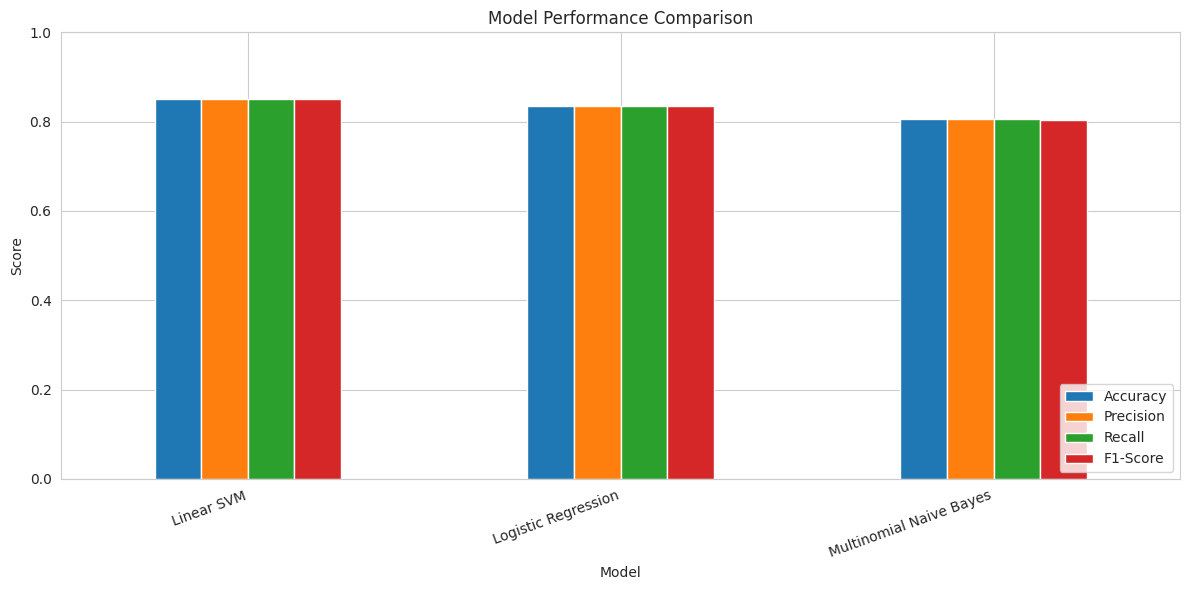

In [31]:

# Visualize model comparison
plot_results = results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
plot_results.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


Error Analysis

This last section looks at examples that the best-performing model got wrong. By reviewing these misclassified cases, we can spot challenging language patterns like ambiguity, sarcasm, mixed opinions, or unusual wording.




In [32]:

# Analyze misclassified examples using the best-performing model
model_predictions = {
    'Logistic Regression': y_pred_lr,
    'Multinomial Naive Bayes': y_pred_nb,
    'Linear SVM': y_pred_svm
}

best_predictions = model_predictions[best_model_name]
misclassified_indices = np.where(best_predictions != y_test.to_numpy())[0]

print(f"Best model: {best_model_name}")
print(f"Number of misclassified examples: {len(misclassified_indices)}")

for idx in misclassified_indices[:5]:
    print("\n" + "=" * 90)
    print(f"Text: {X_test.iloc[idx][:1000]}...")
    print(f"True label:      {y_test.iloc[idx]}")
    print(f"Predicted label: {best_predictions[idx]}")


Best model: Linear SVM
Number of misclassified examples: 60

Text: susan granger's review of bread and tulips first look pictures in this delightfully frothy italian romantic comedy after accidentally being left behind by a tour bus while on a family vacation with her cranky husband and two cynical teenagers rosalba licia maglietta an unhappy housewife from pescara finds herself and love in venice for the first time in years rosalba's on her own when she's abandoned at a highway rest area although her philandering husband antonio catania a plumbing supply dealer orders her to stay there until she's picked up she impulsively accepts a ride to venice a bohemian paradise which she's never visited rosalba finds refuge and romance with fernando bruno ganz a gruff icelandic waiter who offers her a spare room in his modest apartment and prepares breakfast for her each morning to support herself she gets a job working with a florist antonio catania film maker silvio soldini gently explores the

##Part 6: Conclusion

This project shows a full supervised text-classification process. Movie reviews are cleaned, turned into TF-IDF features, and then three machine-learning classifiers are trained and tested using the same stratified train/test split.

The final comparison picks the best model using the weighted F1-score instead of just accuracy. Since the dataset has equal numbers of positive and negative reviews, accuracy is useful, but looking at precision, recall, F1-score, confusion matrices, and individual errors gives a fuller picture.

Key Strengths

* Uses a balanced public sentiment dataset.
* Checks missing values and duplicate rows.
* Preserves important negation words such as not, no, nor, and never.
* Uses unigram and bigram TF-IDF features.
* Fits TF-IDF on training data only, which avoids test-set leakage.
* Compares three different classification algorithms.
* Includes both quantitative metrics and qualitative error analysis.


